In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
 
# Load the data 
df = pd.read_csv("D:/AKRAM/data analysis project/ecommerce_customer_behavior_project/data/raw/E-commerce Customer Behavior - Sheet1.csv") 
 
# First look — always start here 
print("Shape:", df.shape)          # (350, 11) 
print("\nFirst 5 rows:") 
print(df.head()) 
print("\nColumn names and types:") 
print(df.dtypes) 
print("\nBasic stats:") 
print(df.describe()) 

Shape: (350, 11)

First 5 rows:
   Customer ID  Gender  Age           City Membership Type  Total Spend  \
0          101  Female   29       New York            Gold      1120.20   
1          102    Male   34    Los Angeles          Silver       780.50   
2          103  Female   43        Chicago          Bronze       510.75   
3          104    Male   30  San Francisco            Gold      1480.30   
4          105    Male   27          Miami          Silver       720.40   

   Items Purchased  Average Rating  Discount Applied  \
0               14             4.6              True   
1               11             4.1             False   
2                9             3.4              True   
3               19             4.7             False   
4               13             4.0              True   

   Days Since Last Purchase Satisfaction Level  
0                        25          Satisfied  
1                        18            Neutral  
2                        42      

In [2]:
# Check missing values 
print("Missing values per column:") 
print(df.isnull().sum()) 
print("\nMissing value % per column:") 
print((df.isnull().sum() / len(df) * 100).round(2)) 

Missing values per column:
Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          2
dtype: int64

Missing value % per column:
Customer ID                 0.00
Gender                      0.00
Age                         0.00
City                        0.00
Membership Type             0.00
Total Spend                 0.00
Items Purchased             0.00
Average Rating              0.00
Discount Applied            0.00
Days Since Last Purchase    0.00
Satisfaction Level          0.57
dtype: float64


In [3]:
# Check full row duplicates 
print("Duplicate rows:", df.duplicated().sum()) 
 
# Check duplicate Customer IDs (should be 0 since each row = 1 customer) 
print("Duplicate Customer IDs:", df["Customer ID"].duplicated().sum()) 

Duplicate rows: 0
Duplicate Customer IDs: 0


In [4]:
# Unique values in each categorical column 
cat_cols = ["Gender", "City", "Membership Type", "Satisfaction Level"] 
for col in cat_cols: 
    print(f"\n{col}:") 
    print(df[col].value_counts(dropna=False))


Gender:
Gender
Female    175
Male      175
Name: count, dtype: int64

City:
City
New York         59
Los Angeles      59
Chicago          58
San Francisco    58
Miami            58
Houston          58
Name: count, dtype: int64

Membership Type:
Membership Type
Gold      117
Silver    117
Bronze    116
Name: count, dtype: int64

Satisfaction Level:
Satisfaction Level
Satisfied      125
Unsatisfied    116
Neutral        107
NaN              2
Name: count, dtype: int64


In [5]:
# Distribution of numeric columns 
num_cols = ["Age", "Total Spend", "Items Purchased", 
            "Average Rating", "Days Since Last Purchase"] 
 
for col in num_cols: 
    print(f"\n{col}:") 
    print(f"  Min: {df[col].min():.1f}  |  Max: {df[col].max():.1f}") 
    print(f"  Mean: {df[col].mean():.1f}  |  Median: {df[col].median():.1f}") 
    print(f"  Std Dev: {df[col].std():.1f}") 


Age:
  Min: 26.0  |  Max: 43.0
  Mean: 33.6  |  Median: 32.5
  Std Dev: 4.9

Total Spend:
  Min: 410.8  |  Max: 1520.1
  Mean: 845.4  |  Median: 775.2
  Std Dev: 362.1

Items Purchased:
  Min: 7.0  |  Max: 21.0
  Mean: 12.6  |  Median: 12.0
  Std Dev: 4.2

Average Rating:
  Min: 3.0  |  Max: 4.9
  Mean: 4.0  |  Median: 4.1
  Std Dev: 0.6

Days Since Last Purchase:
  Min: 9.0  |  Max: 63.0
  Mean: 26.6  |  Median: 23.0
  Std Dev: 13.4


In [6]:
# Check which rows have missing Satisfaction Level 
missing_sat = df[df["Satisfaction Level"].isnull()] 
print(missing_sat) 
 
# Option A: Drop them (only 2 rows = 0.57% of data) 
df_clean = df.dropna(subset=["Satisfaction Level"]) 
 
# Option B: Fill with "Unknown" to keep them in non-satisfaction analysis 
# df["Satisfaction Level"] = df["Satisfaction Level"].fillna("Unknown") 
 
# RECOMMENDATION: Drop — 2 rows is negligible and keeps analysis clean 
df_clean = df.dropna(subset=["Satisfaction Level"]).copy() 
print(f"Rows after dropping: {len(df_clean)}")  # Should be 348 

     Customer ID  Gender  Age     City Membership Type  Total Spend  \
71           172  Female   37  Houston          Bronze        420.8   
143          244  Female   37  Houston          Bronze        430.8   

     Items Purchased  Average Rating  Discount Applied  \
71                 7             3.1             False   
143                7             3.4             False   

     Days Since Last Purchase Satisfaction Level  
71                         21                NaN  
143                        23                NaN  
Rows after dropping: 348


In [9]:
# Check current data types 
print(df_clean.dtypes) 
 
# Discount Applied is already bool — confirm it 
print(df_clean["Discount Applied"].dtype)  # Should be bool 
 
# Convert Satisfaction Level to Ordered Categorical 
# This allows proper ordering: Unsatisfied < Neutral < Satisfied 
sat_order = ["Unsatisfied", "Neutral", "Satisfied"] 
df_clean["Satisfaction Level"] = pd.Categorical( 
    df_clean["Satisfaction Level"], 
    categories=sat_order, 
    ordered=True 
)
# Convert Membership Type to Ordered Categorical 
mem_order = ["Bronze", "Silver", "Gold"] 
df_clean["Membership Type"] = pd.Categorical( 
    df_clean["Membership Type"], 
    categories=mem_order, 
    ordered=True 
)

Customer ID                    int64
Gender                        object
Age                            int64
City                          object
Membership Type             category
Total Spend                  float64
Items Purchased                int64
Average Rating               float64
Discount Applied                bool
Days Since Last Purchase       int64
Satisfaction Level          category
dtype: object
bool


In [11]:
# 1. Spend per Item (efficiency metric) 
df_clean["Spend Per Item"] = df_clean["Total Spend"] / df_clean["Items Purchased"] 
 
# 2. Customer Value Segment (spend-based) 
df_clean["Spend Segment"] = pd.cut( 
    df_clean["Total Spend"], 
    bins=[0, 600, 1000, 1600], 
    labels=["Low (<$600)", "Mid ($600-$1000)", "High (>$1000)"] 
) 
 
# 3. Churn Risk Flag (based on recency) 
df_clean["Churn Risk"] = df_clean["Days Since Last Purchase"].apply( 
    lambda x: "High Risk" if x > 45 else ("Medium Risk" if x > 25 else "Low Risk") 
) 
 
# 4. Age Group 
df_clean["Age Group"] = pd.cut( 
    df_clean["Age"], 
    bins=[25, 30, 35, 40, 45], 
    labels=["26-30", "31-35", "36-40", "41-43"] 
) 
 
# Save clean data 
df_clean.to_csv("D:/AKRAM/data analysis project/ecommerce_customer_behavior_project/data/processed/customers_clean.csv", index=False) 
print(f"Clean dataset saved: {df_clean.shape}")

Clean dataset saved: (348, 15)


In [12]:
# Always validate after cleaning — confirm nothing broke 
print("=== POST-CLEANING VALIDATION ===") 
print(f"Rows: {len(df_clean)} (was 350, dropped 2)")   
print(f"Missing values:\n{df_clean.isnull().sum()}") 
print(f"New columns: {[c for c in df_clean.columns if c not in df.columns]}") 
print(f"Spend Segment distribution:\n{df_clean['Spend Segment'].value_counts()}") 
print(f"Churn Risk distribution:\n{df_clean['Churn Risk'].value_counts()}") 

=== POST-CLEANING VALIDATION ===
Rows: 348 (was 350, dropped 2)
Missing values:
Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          0
Spend Per Item              0
Spend Segment               0
Churn Risk                  0
Age Group                   0
dtype: int64
New columns: ['Spend Per Item', 'Spend Segment', 'Churn Risk', 'Age Group']
Spend Segment distribution:
Spend Segment
Mid ($600-$1000)    117
High (>$1000)       117
Low (<$600)         114
Name: count, dtype: int64
Churn Risk distribution:
Churn Risk
Low Risk       194
Medium Risk    113
High Risk       41
Name: count, dtype: int64


In [19]:
import matplotlib.pyplot as plt 
import seaborn as sns 
 
# Professional style settings 
plt.style.use("seaborn-v0_8-whitegrid") 
sns.set_palette("Blues_d") 
 
COLORS = { 
    "blue": "#2E75B6", 
    "orange": "#E67E22", 
    "green": "#27AE60", 
    "red": "#C0392B", 
    "purple": "#7D3C98" 
} 
 
# Function to save charts consistently 
def save_chart(filename):
    plt.tight_layout()
    plt.savefig(f"D:/AKRAM/data analysis project/ecommerce_customer_behavior_project/visualizations/{filename}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

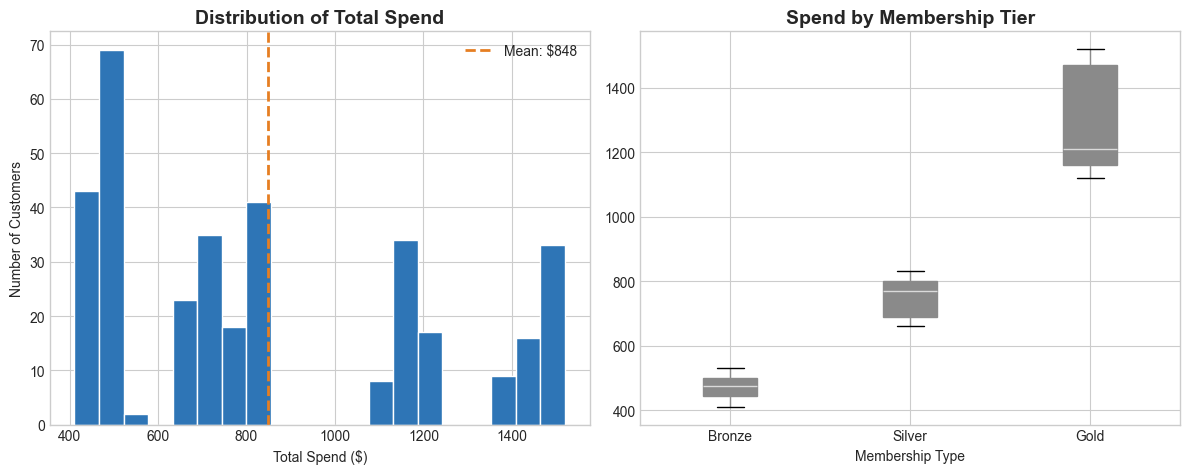

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 
 
# Histogram 
axes[0].hist(df_clean["Total Spend"], bins=20, color=COLORS["blue"], 
edgecolor="white") 
axes[0].axvline(df_clean["Total Spend"].mean(), color=COLORS["orange"], 
                linestyle="--", linewidth=2, label=f'Mean: ${df_clean["Total Spend"].mean():.0f}') 
axes[0].set_title("Distribution of Total Spend", fontsize=14, fontweight="bold") 
axes[0].set_xlabel("Total Spend ($)") 
axes[0].set_ylabel("Number of Customers") 
axes[0].legend() 
 
# Box plot by membership 
df_clean.boxplot(column="Total Spend", by="Membership Type", 
                 ax=axes[1], patch_artist=True) 
axes[1].set_title("Spend by Membership Tier", fontsize=14, fontweight="bold") 
axes[1].set_xlabel("Membership Type") 
plt.suptitle("")  # Remove auto-title from boxplot 
 
save_chart("01_spend_distribution") 

C:\Users\AKRAM\AppData\Local\Temp\ipykernel_17940\651507286.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  spend_by_mem = df_clean.groupby("Membership Type")["Total Spend"].mean().reset_index()


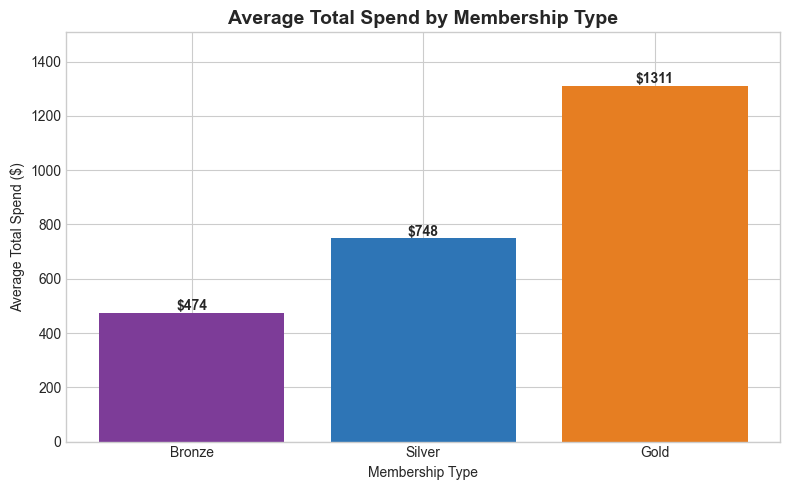

In [23]:
plt.figure(figsize=(8, 5)) 
 
spend_by_mem = df_clean.groupby("Membership Type")["Total Spend"].mean().reset_index() 
 
bars = plt.bar(spend_by_mem["Membership Type"], 
               spend_by_mem["Total Spend"], 
               color=[COLORS["purple"], COLORS["blue"], COLORS["orange"]]) 
 
# Add value labels on bars 
for bar, val in zip(bars, spend_by_mem["Total Spend"]): 
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
             f"${val:.0f}", ha="center", fontweight="bold") 
 
plt.title("Average Total Spend by Membership Type", fontsize=14, 
fontweight="bold") 
plt.xlabel("Membership Type") 
plt.ylabel("Average Total Spend ($)") 
plt.ylim(0, max(spend_by_mem["Total Spend"]) * 1.15) 
 
save_chart("02_spend_by_membership") 

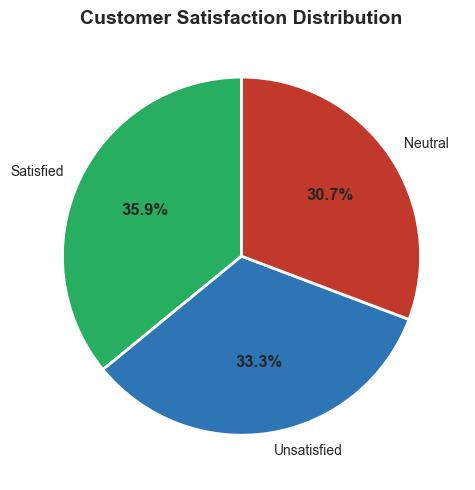

In [24]:
plt.figure(figsize=(7, 5)) 
 
sat_counts = df_clean["Satisfaction Level"].value_counts() 
colors_sat = [COLORS["green"], COLORS["blue"], COLORS["red"]] 
 
wedges, texts, autotexts = plt.pie( 
    sat_counts.values, 
    labels=sat_counts.index, 
    autopct="%1.1f%%", 
    colors=colors_sat, 
    startangle=90, 
    wedgeprops={"edgecolor": "white", "linewidth": 2} 
) 
 
for text in autotexts: 
    text.set_fontweight("bold") 
    text.set_fontsize(12) 
 
plt.title("Customer Satisfaction Distribution", fontsize=14, fontweight="bold") 
save_chart("03_satisfaction_distribution")

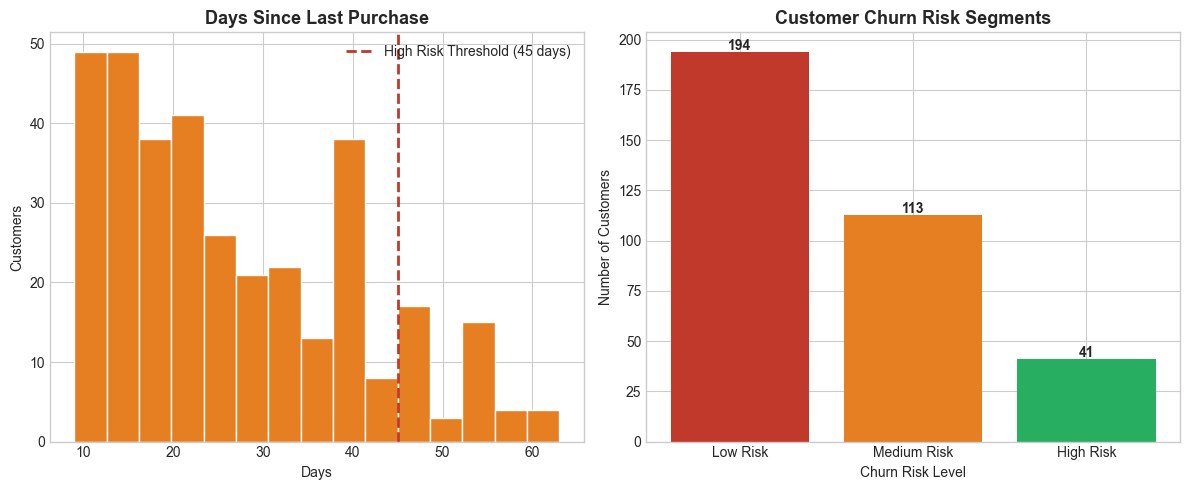

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 
 
# Distribution of days 
axes[0].hist(df_clean["Days Since Last Purchase"], bins=15, 
             color=COLORS["orange"], edgecolor="white") 
axes[0].axvline(45, color=COLORS["red"], linestyle="--", 
                linewidth=2, label="High Risk Threshold (45 days)") 
axes[0].set_title("Days Since Last Purchase", fontsize=13, fontweight="bold") 
axes[0].set_xlabel("Days") 
axes[0].set_ylabel("Customers") 
axes[0].legend() 
 
# Churn risk segments 
risk_counts = df_clean["Churn Risk"].value_counts() 
axes[1].bar(risk_counts.index, risk_counts.values, 
            color=[COLORS["red"], COLORS["orange"], COLORS["green"]]) 
axes[1].set_title("Customer Churn Risk Segments", fontsize=13, fontweight="bold") 
axes[1].set_xlabel("Churn Risk Level") 
axes[1].set_ylabel("Number of Customers") 
 
for i, (idx, val) in enumerate(risk_counts.items()): 
    axes[1].text(i, val + 1, str(val), ha="center", fontweight="bold") 
 
save_chart("04_churn_risk") 
 


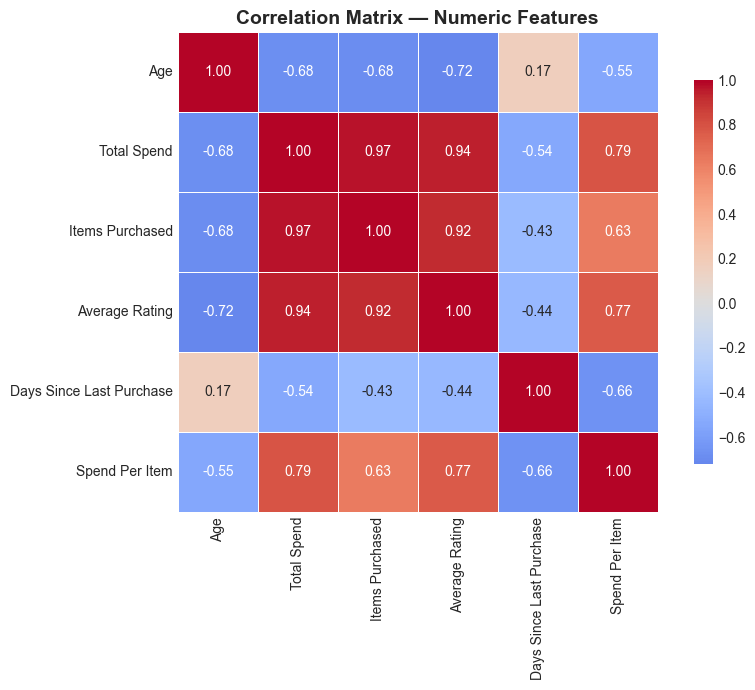

In [27]:
plt.figure(figsize=(9, 7)) 
 
num_cols = ["Age", "Total Spend", "Items Purchased", 
            "Average Rating", "Days Since Last Purchase", "Spend Per Item"] 
 
corr_matrix = df_clean[num_cols].corr() 
 
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1) 
 
sns.heatmap( 
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    center=0, 
    square=True, 
    linewidths=0.5, 
    cbar_kws={"shrink": 0.8} 
) 
 
plt.title("Correlation Matrix — Numeric Features", fontsize=14, fontweight="bold") 
save_chart("05_correlation_heatmap") 

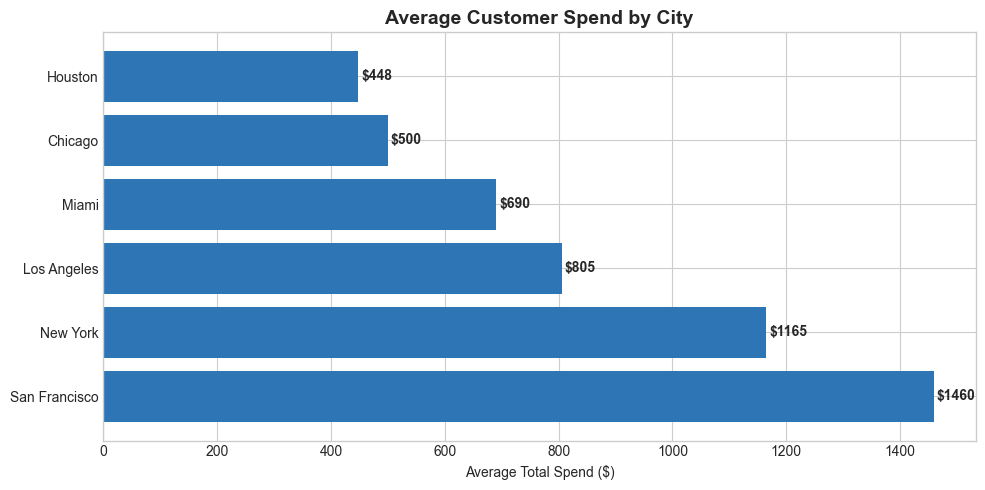

In [29]:
plt.figure(figsize=(10, 5)) 
 
city_spend = df_clean.groupby("City")["Total Spend"].mean().sort_values(ascending=False) 
 
bars = plt.barh(city_spend.index, city_spend.values, color=COLORS["blue"]) 
 
for bar, val in zip(bars, city_spend.values): 
    plt.text(val + 5, bar.get_y() + bar.get_height()/2, 
             f"${val:.0f}", va="center", fontweight="bold") 
 
plt.title("Average Customer Spend by City", fontsize=14, fontweight="bold") 
plt.xlabel("Average Total Spend ($)") 
plt.ylabel("") 
save_chart("06_spend_by_city")

C:\Users\AKRAM\AppData\Local\Temp\ipykernel_17940\3194853559.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disc_sat = df_clean.groupby(["Discount Applied", "Satisfaction Level"]).size().unstack()


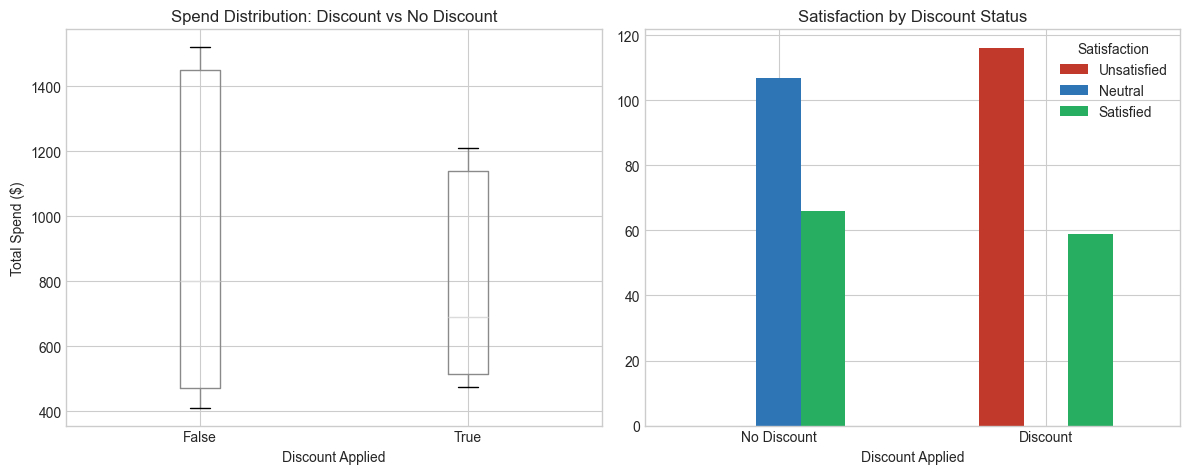

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 
 
# Box plot 
df_clean.boxplot(column="Total Spend", by="Discount Applied", ax=axes[0]) 
axes[0].set_title("Spend Distribution: Discount vs No Discount") 
axes[0].set_xlabel("Discount Applied") 
axes[0].set_ylabel("Total Spend ($)") 
plt.suptitle("") 
 
# Satisfaction by discount 
disc_sat = df_clean.groupby(["Discount Applied", "Satisfaction Level"]).size().unstack() 
disc_sat.plot(kind="bar", ax=axes[1], 
              color=[COLORS["red"], COLORS["blue"], COLORS["green"]]) 
axes[1].set_title("Satisfaction by Discount Status") 
axes[1].set_xlabel("Discount Applied") 
axes[1].set_xticklabels(["No Discount", "Discount"], rotation=0) 
axes[1].legend(title="Satisfaction") 
 
save_chart("07_discount_analysis") 

C:\Users\AKRAM\AppData\Local\Temp\ipykernel_17940\3747721780.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gender_mem_spend = df_clean.groupby(


<Figure size 1000x600 with 0 Axes>

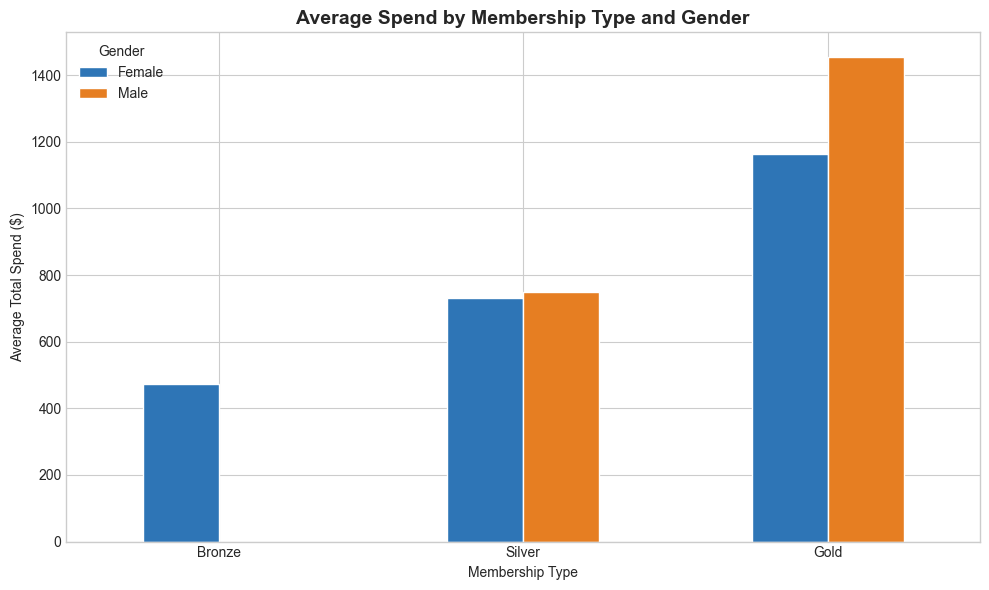

In [32]:
plt.figure(figsize=(10, 6)) 
gender_mem_spend = df_clean.groupby( 
["Membership Type", "Gender"])["Total Spend"].mean().unstack() 
gender_mem_spend.plot( 
kind="bar", 
color=[COLORS["blue"], COLORS["orange"]], 
edgecolor="white", 
figsize=(10, 6) 
) 
plt.title("Average Spend by Membership Type and Gender", 
fontsize=14, fontweight="bold") 
plt.xlabel("Membership Type") 
plt.ylabel("Average Total Spend ($)") 
plt.xticks(rotation=0) 
plt.legend(title="Gender") 
save_chart("08_gender_membership_spend")